In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Basic Statistics ===')
df.describe()

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Basic Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# 0 values medically impossible hain in columns mein
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0 ko NaN se replace karo
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# NaN ko median se fill karo
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

print('Cleaning complete!')
print('\nMissing values after cleaning:')
print(df.isnull().sum())
df.head()

Cleaning complete!

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


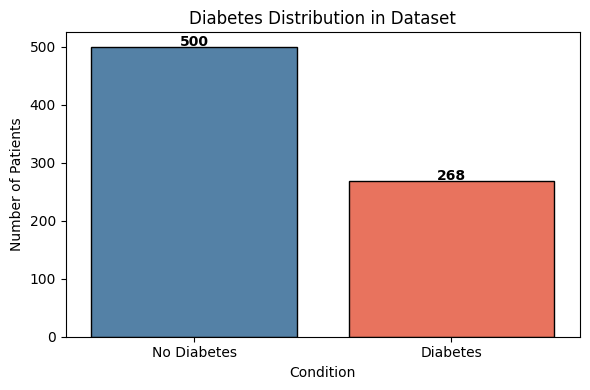

No Diabetes : 500
Diabetes    : 268


In [5]:
counts = df['Outcome'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values,
            palette=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.title('Diabetes Distribution in Dataset')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'No Diabetes : {counts[0]}')
print(f'Diabetes    : {counts[1]}')

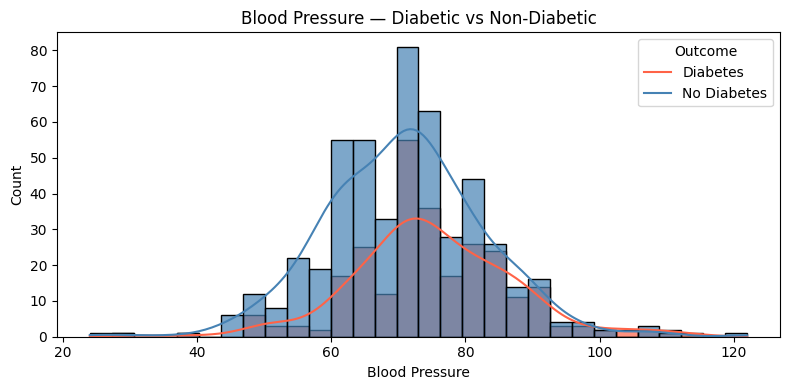

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='BloodPressure', hue='Outcome', bins=30,
             kde=True, palette={0: 'steelblue', 1: 'tomato'}, alpha=0.7)
plt.title('Blood Pressure — Diabetic vs Non-Diabetic')
plt.xlabel('Blood Pressure')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Diabetes', 'No Diabetes'])
plt.tight_layout()
plt.show()

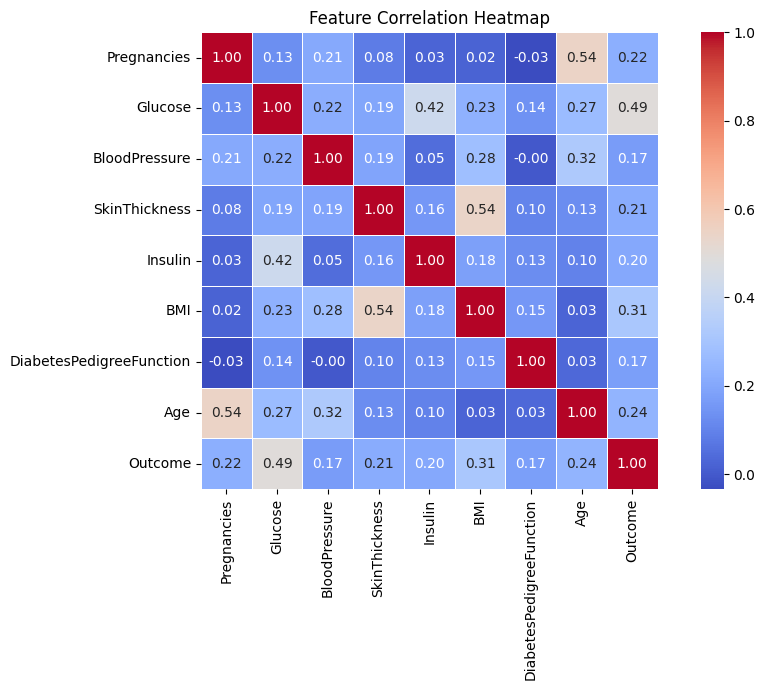

In [7]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [8]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print('Features (X) shape:', X.shape)
print('Target  (y) shape :', y.shape)
print('\nFeature columns:')
print(X.columns.tolist())

Features (X) shape: (768, 8)
Target  (y) shape : (768,)

Feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
